In [1]:
import glob, json, math, time, os
import numpy as np
import sys
import matplotlib.pyplot as plt
import h5py
from scipy import stats

utils_dir = "/n/home07/tshelley2002/Uncertainty_Project/cl4ad_new/NPLM_testing/code_updated/utils"
if utils_dir not in sys.path:
    sys.path.insert(0, utils_dir)

import PLOTutils_Analysis
from PLOTutils_Analysis import *
from ANALYSISutils import *
from READJSONutils import *

In [39]:
def plot_2distribution1(t1, t2, df, xmin=0, xmax=300, nbins=10,
                       label1='1', label2='2', save=False, save_path='', file_name=''):
    
    '''
    Plot the histogram of two test statistics samples (t1 and t2) and the target chi2 distribution.
    The median and the error on the median are calculated and thus the median Z-score and its error.
    
    t1:  (numpy array shape (None,))
    t2:  (numpy array shape (None,))
    df: (int) chi2 degrees of freedom
    '''
    
    plt.rcParams["font.family"] = "serif"
    plt.style.use('classic')
    fig = plt.figure(figsize=(12, 9))
    fig.patch.set_facecolor('white')

    # plot distribution histogram
    bins = np.linspace(xmin, xmax, nbins + 1)
    binswidth = (xmax - xmin) * 1. / nbins

    # -------------------------
    # t1
    # -------------------------
    med1 = np.median(t1)
    Z_obs = norm.ppf(chi2.cdf(med1, df))
    t_obs_err = 1.2533 * np.std(t1) * 1. / np.sqrt(t1.shape[0])
    Z_obs_p = norm.ppf(chi2.cdf(med1 + t_obs_err, df))
    Z_obs_m = norm.ppf(chi2.cdf(med1 - t_obs_err, df))

    label = r'Test statistics of modeled $R_{\nu = 0.05}$'

    h = plt.hist(
        t1,
        weights=np.ones_like(t1) * 1. / (t1.shape[0] * binswidth),
        color='lightblue',
        ec='#2c7fb8',
        alpha=0.55,
        bins=bins,
        label=label
    )

    err = np.sqrt(h[0] / (t1.shape[0] * binswidth))
    x = 0.5 * (bins[1:] + bins[:-1])
    plt.errorbar(x, h[0], yerr=err, color='#2c7fb8', marker='o', ls='')

    # median line for t1
    plt.axvline(
        med1,
        color='blue',
        linestyle='--',
        linewidth=2.2,
        label=rf'Median (Modeled $R_{{\nu=0.05}}$): {med1:.2f}'
    )

    # -------------------------
    # t2
    # -------------------------
    med2 = np.median(t2)
    Z_obs = norm.ppf(chi2.cdf(med2, df))
    t_obs_err = 1.2533 * np.std(t2) * 1. / np.sqrt(t2.shape[0])
    Z_obs_p = norm.ppf(chi2.cdf(med2 + t_obs_err, df))
    Z_obs_m = norm.ppf(chi2.cdf(med2 - t_obs_err, df))

    label = r'Benchmarked test statistics ($R_{0}$)'

    h = plt.hist(
        t2,
        weights=np.ones_like(t2) * 1. / (t2.shape[0] * binswidth),
        color='pink',
        ec='deeppink',
        alpha=0.27,
        bins=bins,
        label=label
    )

    err = np.sqrt(h[0] / (t2.shape[0] * binswidth))
    x = 0.5 * (bins[1:] + bins[:-1])
    plt.errorbar(x, h[0], yerr=err, color='deeppink', marker='o', ls='')

    # median line for t2
    plt.axvline(
        med2,
        color='deeppink',
        linestyle='--',
        linewidth=2.2,
        label=f'Median (Benchmark): {med2:.2f}'
    )

    # -------------------------
    # reference chi2
    # -------------------------
    x = np.linspace(chi2.ppf(0.0001, df), chi2.ppf(0.9999, df), 100)
    plt.plot(x, chi2.pdf(x, df), 'midnightblue', lw=5, alpha=0.8, label=r'$\chi^2$(' + str(df) + ')')

    font = font_manager.FontProperties(family='serif', size=14)
    plt.legend(ncol=1, loc='upper right', prop=font, fontsize=100)

    plt.xlabel('t', fontsize=16, fontname="serif")
    plt.ylabel('Probability', fontsize=16, fontname="serif")
    plt.ylim(0., np.max(chi2.pdf(x, df)) * 1.3)
    plt.yticks(fontsize=16, fontname="serif")
    plt.xticks(fontsize=16, fontname="serif")

    if save:
        if save_path == '':
            print('argument save_path is not defined. The figure will not be saved.')
        else:
            if file_name == '':
                file_name = '2distribution'
            else:
                file_name += '_2distribution'
            plt.savefig(save_path + file_name + '.pdf')

    plt.show()
    plt.close()
    return

In [70]:
def plot_1distribution(t, df, xmin=0, xmax=300, nbins=10, label='', save=False, save_path='', file_name=''):
    '''
    Plot the histogram of a test statistics sample (t) and the target chi2 distribution. 
    The median and the error on the median are calculated in order to calculate the median Z-score and its error.
    
    t:  (numpy array shape (None,))
    df: (int) chi2 degrees of freedom
    '''
    plt.rcParams["font.family"] = "serif"
    plt.style.use('classic')
    fig  = plt.figure(figsize=(12, 9))
    fig.patch.set_facecolor('white')
    # plot distribution histogram
    bins      = np.linspace(xmin, xmax, nbins+1)
    Z_obs     = norm.ppf(chi2.cdf(np.median(t), df))
    t_obs_err = 1.2533*np.std(t)*1./np.sqrt(t.shape[0])
    Z_obs_p   = norm.ppf(chi2.cdf(np.median(t)+t_obs_err, df))
    Z_obs_m   = norm.ppf(chi2.cdf(np.median(t)-t_obs_err, df))
    label  = 'Test statistics, t'
    #label  = 'sample %s\nsize: %i \nmedian: %s, std: %s\n'%(label, t.shape[0], str(np.around(np.median(t), 2)),str(np.around(np.std(t), 2)))
    label += '\nZ = %s (+%s/-%s)'%(str(np.around(Z_obs, 2)), str(np.around(Z_obs_p-Z_obs, 2)), str(np.around(Z_obs-Z_obs_m, 2)))
    binswidth = (xmax-xmin)*1./nbins
    h = plt.hist(t, weights=np.ones_like(t)*1./(t.shape[0]*binswidth), color='lightblue', ec='#2c7fb8',
                 bins=bins, label=label)
    err = np.sqrt(h[0]/(t.shape[0]*binswidth))
    x   = 0.5*(bins[1:]+bins[:-1])
    plt.errorbar(x, h[0], yerr = err, color='#2c7fb8', marker='o', ls='')
    # plot reference chi2
    x  = np.linspace(chi2.ppf(0.0001, df), chi2.ppf(0.9999, df), 100)
    plt.plot(x, chi2.pdf(x, df),'midnightblue', lw=5, alpha=0.8, label=r'$\chi^2$('+str(df)+')')
    
    # median line for t2
    plt.axvline(
        np.median(t),
        color='midnightblue',
        linestyle='--',
        linewidth=2.2,
        label=f'Median: {np.median(t):.2f}'
    )
    
    font = font_manager.FontProperties(family='serif', size=20) 
    plt.legend(prop=font)
    plt.xlabel('t', fontsize=18, fontname="serif")
    plt.ylabel('Probability', fontsize=18, fontname="serif")
    plt.yticks(fontsize=16, fontname="serif")
    plt.xticks(fontsize=16, fontname="serif")
    if save:
        if save_path=='': print('argument save_path is not defined. The figure will not be saved.')
        else:
            if file_name=='': file_name = '1distribution'
            else: file_name += '_1distribution'
            plt.savefig(save_path+file_name+'.pdf')
    plt.show()
    plt.close(fig)
    return

In [71]:
def plots(R0_folder_list):
    return_list = []
    for i in range(0,len(R0_folder_list)):
    
        
        R0_folder = R0_folder_list[i]
        print("WC:", R0_folder[-4:-1])
        
        taus_R0, deltas_R0, tau_hist_R0, delta_hist_R0, nparamslist_R0, files_R0 = collect_results_with_nparams_from_config(R0_folder)
        nparams = nparamslist_R0[0]
        taus_R0, deltas_R0 = np.array(taus_R0),np.array(deltas_R0)
    
        t_hist = np.empty((len(tau_hist_R0),len(tau_hist_R0[0])))
        delta_hist=np.empty((len(delta_hist_R0),len(delta_hist_R0[0])))
        for l in range(0,len(delta_hist_R0)):
            delta_hist[l] = -2 * np.array(delta_hist_R0[l])
        for j in range(0,len(delta_hist_R0)):
            for n in range(0,len(tau_hist_R0[j])-len(delta_hist_R0[j])):
                delta_hist_R0[j].append(delta_hist_R0[j][-1])
        for k in range(0,len(tau_hist_R0)):
            t_hist[k] = -2 * (np.array(tau_hist_R0[k]) - np.array(delta_hist_R0[k]))
            
        # plot_2distribution(taus_R0, taus_R0-deltas_R0, df=nparams, xmin=0, xmax=100, nbins=15,  
        #                    label1=r'$\tau(R_0,\,A), $', label2=r'$\tau(R_0,\,A)-\Delta(R_0,\,A)$, ',
        #                    save=False, save_path='', file_name='')
        
        plot_1distribution((taus_R0-deltas_R0)[:100], df=nparams, xmin=0, xmax=160, nbins=15,  
                            label='',
                            save=False, save_path='', file_name='')
        # plot_1distribution(deltas_R0, df=2, xmin=0, xmax=10, nbins=10,  
        #                 label=r'$\Delta(D,\,A)$',
        #                 save=False, save_path='', file_name='')
        #Plot_Percentiles_ref(t_hist, nparams,ymin = 0, ymax=120)
        #Plot_Percentiles_ref(delta_hist, 2, ymin = -1, ymax=2000)
        return_list.append([taus_R0, deltas_R0,  t_hist, delta_hist])
    return return_list,nparams


WC: .97


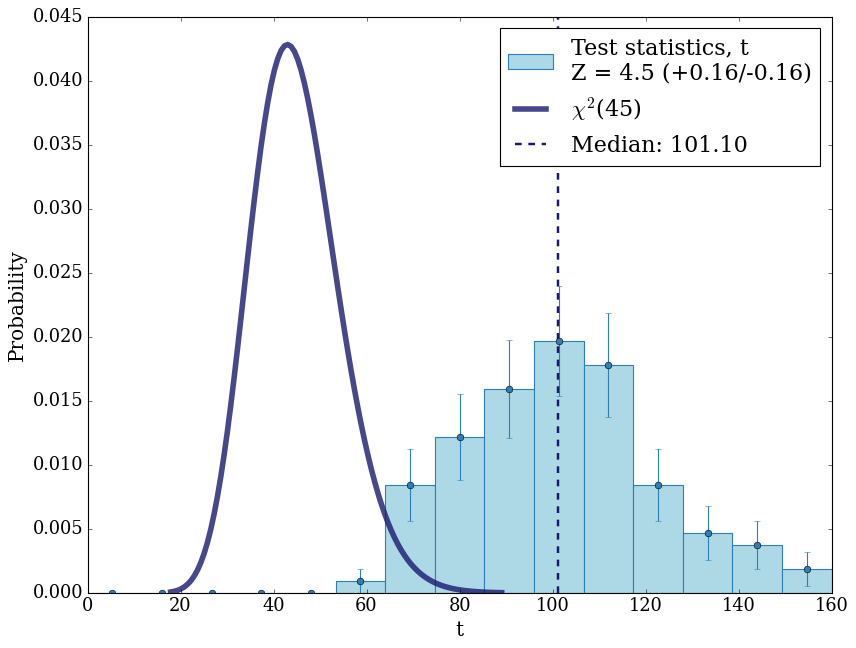

WC: .97


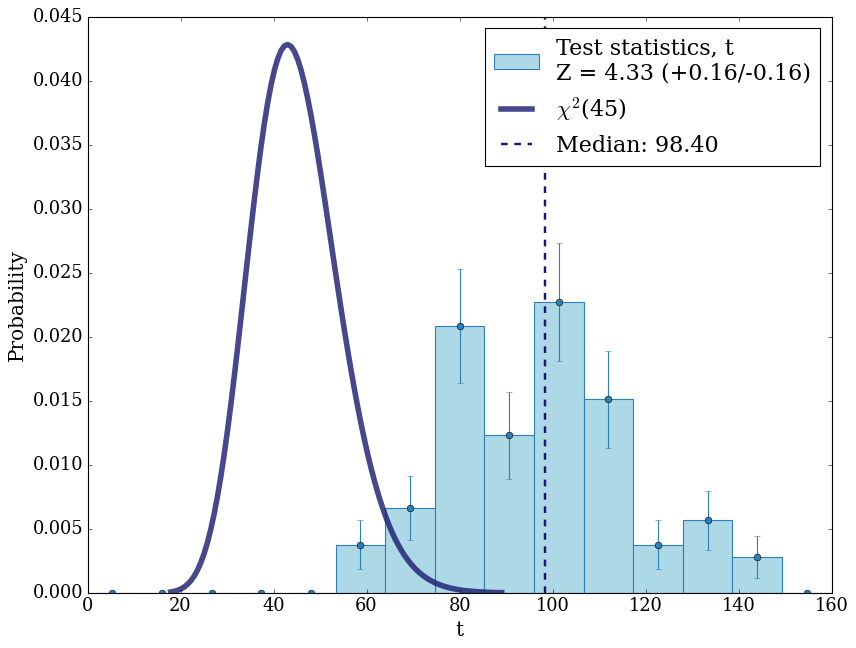

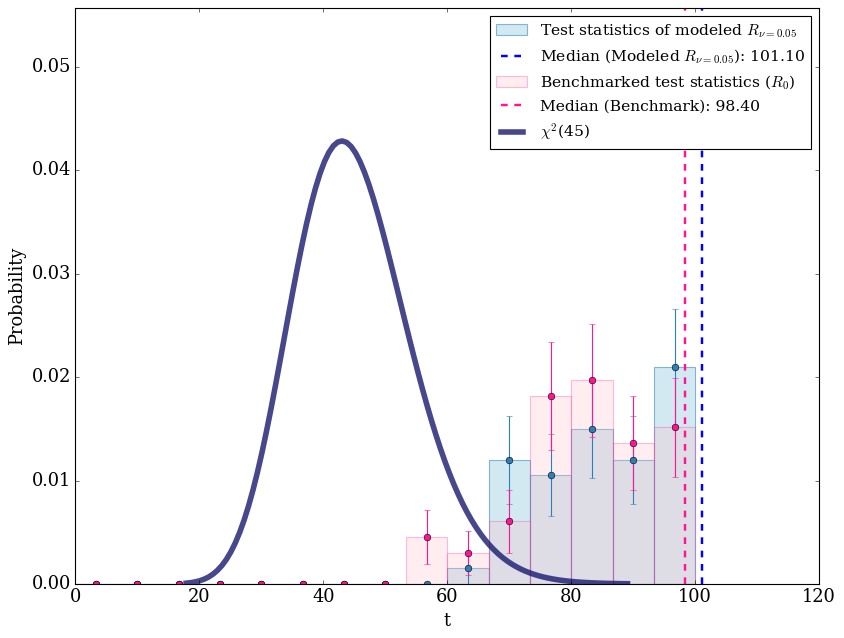

In [74]:
return_list,nparams = plots(["/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test7/D/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale0.05_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.97/",
       "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test7/R0/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.97/"])
taus_D,deltas_D, taus_R0,deltas_R0= return_list[0][0], return_list[0][1],return_list[1][0],return_list[1][1]

plot_2distribution1(
    (taus_D - deltas_D)[:100],
    (taus_R0 - deltas_R0)[:100],
    df=nparams, 
    xmin=0, xmax=100, nbins=15,
    label1=r"$",
    label2=r"$\tau(R_0,A)-\Delta(R_0,A)$",)

WC: .95
WC: .95


/n/home07/tshelley2002/.conda/envs/falkon_src/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 120642 (\N{MATHEMATICAL BOLD ITALIC SMALL NU}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


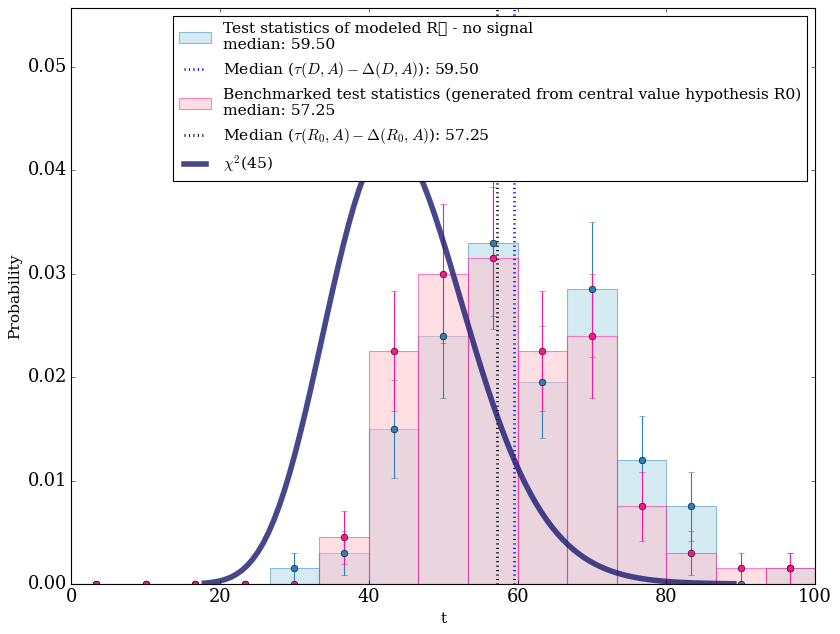

In [14]:
return_list,nparams = plots(["/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test7/D/hChToTauNu/Nref18200_Nbkg3500_Nsig35/SHAPE1_nuscale0.05_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.95/",
       "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test7/R0/hChToTauNu/Nref18200_Nbkg3500_Nsig35/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.95/"])
taus_D,deltas_D, taus_R0,deltas_R0= return_list[0][0], return_list[0][1],return_list[1][0],return_list[1][1]

plot_2distribution1(
    (taus_D - deltas_D)[:100],
    (taus_R0 - deltas_R0)[:100],
    df=nparams, 
    xmin=0, xmax=100, nbins=15,
    label1=r"$\tau(D,A)-\Delta(D,A)$",
    label2=r"$\tau(R_0,A)-\Delta(R_0,A)$",)

    # alpha=0.4,
    # color1="lightblue",
    # color2="pink",)
# return_list = plots(["/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test7/D/Nref52000_Nbkg10000_Nsig0/SHAPE1_nuscale0.05_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.9/",
#        "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test7/R0/Nref52000_Nbkg10000_Nsig0/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.9/"])